In [1]:
import pandas as pd
import os 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.colors as mcolors

In [2]:
df = pd.read_csv('../banco_fenotipos_conformal.csv') # Load the phenotypic data
df = df.drop(columns=['id','samplefilename', 'CP1','CP2','CP3','CP4','CP5','CP6']) # remove the id from the table
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int) # Turns the categorical columns into 0 and 1
colunas_categoricas = [coluna for coluna in df.columns if df[coluna].nunique() < 6]

In [3]:
df.columns

Index(['hb_g_dl', 'glicose_mg_dl', 'sexo', 'idade', 'faixa_etaria', 'imc',
       'imc_cat4_aferido', 'imc_cat_aferido', 'ep', 'obesidade', 'ccm',
       'obes_central', 'cc_estat', 'cc_estat_cat', 'medDM_bioq', 'diabetes2',
       'HOMA_IR', 'HOMA_cat', 'pas_final', 'pad_final', 'medHAS_bioq', 'has2',
       'col_nao_hdlc_mg_dl', 'colnaohdl_cat', 'fumo_fumante', 'fumo_nunca',
       'fumo_não respondeu', 'raca_cor_branca', 'raca_cor_indígena',
       'raca_cor_não respondeu', 'raca_cor_outras', 'raca_cor_parda',
       'raca_cor_preta', 'conjugal3_casado/un. estavel',
       'conjugal3_separado/desq/divorc', 'conjugal3_solteiro',
       'conjugal3_viuvo', 'trabalho2_estudante', 'trabalho2_nÃ£o trabalha',
       'trabalho2_trabalha', 'bebem2_NS/NR', 'bebem2_atÃ© 3x semana',
       'bebem2_nÃ£o bebe'],
      dtype='str')

In [4]:
nrespondeu = [coluna for coluna in df.columns if 'respondeu' in coluna]
df = df.drop(columns=nrespondeu)

In [5]:
df = df.rename(columns={
    'hb_g_dl': 'hemoglobina_g_dl',
    'glicose_mg_dl': 'glicose_mg_dl',
    'sexo': 'sexo',
    'idade': 'idade',
    'faixa_etaria': 'faixa_etaria',
    'imc': 'imc',
    'imc_cat4_aferido': 'imc_categoria_4',
    'imc_cat_aferido': 'imc_categoria',
    'ep': 'excesso_peso',
    'obesidade': 'obesidade',
    'ccm': 'circunferencia_cintura_cm',
    'obes_central': 'obesidade_central',
    'cc_estat': 'circ_cintura_estatura',
    'cc_estat_cat': 'circ_cintura_estatura_cat',
    'medDM_bioq': 'medicamento_dm_bioq',
    'diabetes2': 'diabetes_tipo_2',
    'HOMA_IR': 'homa_ir',
    'HOMA_cat': 'homa_categoria',
    'pas_final': 'pressao_sistolica_final',
    'pad_final': 'pressao_diastolica_final',
    'medHAS_bioq': 'medicamento_has_bioq',
    'has2': 'hipertensao_tipo_2',
    'col_nao_hdlc_mg_dl': 'colesterol_nao_hdl_mg_dl',
    'colnaohdl_cat': 'colesterol_nao_hdl_cat',
    'fumo_fumante': 'fumo_fumante',
    'fumo_nunca': 'fumo_nunca',
    'raca_cor_branca': 'raca_cor_branca',
    'raca_cor_indígena': 'raca_cor_indigena',
    'raca_cor_outras': 'raca_cor_outras',
    'raca_cor_parda': 'raca_cor_parda',
    'raca_cor_preta': 'raca_cor_preta',
    'conjugal3_casado/un. estavel': 'estado_civil_casado_uniao_est',
    'conjugal3_separado/desq/divorc': 'estado_civil_separado_divorc',
    'conjugal3_solteiro': 'estado_civil_solteiro',
    'conjugal3_viuvo': 'estado_civil_viuvo',
    'trabalho2_estudante': 'trabalho_estudante',
    'trabalho2_nÃ£o trabalha': 'trabalho_nao_trabalha',
    'trabalho2_trabalha': 'trabalho_trabalha',
    'bebem2_NS/NR': 'consumo_alcool_ns_nr',
    'bebem2_atÃ© 3x semana': 'consumo_alcool_ate_3x_semana',
    'bebem2_nÃ£o bebe': 'consumo_alcool_nao_bebe'
})

In [6]:
def extrair_frequencia_estabilidade_grafo(
    df, alvos, num_trees=500, iteracoes=50, fracao_amostra=0.5, q=3
):
    """Extrai a frequência de estabilidade das arestas baseado no artigo

    Fellinghauer et al. (2013).

    Parâmetros:
    - q: Número de top variáveis com maior importância que serão selecionadas
         em cada iteração (frequência binária).
    """
    # Matriz inicializada com zeros
    matriz_estabilidade = pd.DataFrame(
        index=alvos, columns=df.columns, dtype=np.float64
    ).fillna(0.0)

    for target in alvos:
        print(f"Rodando a variável {target}")
        df_alvo = df.dropna(subset=[target])

        for i in range(iteracoes):
            if fracao_amostra > 1:
                df_sub = df_alvo.sample(n=fracao_amostra, random_state=i)
            else:
                df_sub = df_alvo.sample(frac=fracao_amostra, random_state=i)
            

            X = df_sub.drop(columns=[target])
            y = df_sub[target]

            if target not in colunas_categoricas:
                modelorf = RandomForestRegressor(
                    n_estimators=num_trees,
                    max_features=0.3,
                    n_jobs = -1,
                    bootstrap=False,
                )
            else:
                modelorf = RandomForestClassifier(
                    n_estimators=num_trees,
                    max_features=0.3,
                    class_weight='balanced',
                    bootstrap=False, # Bootstrap ligado e 1 iteracao, e 100% dos dados
                    n_jobs = -1,
                )

            modelorf.fit(X, y)

            resultado_permutacao = permutation_importance(
                modelorf, X, y, n_repeats=3, random_state=i, n_jobs=-1
            )
            importancias = resultado_permutacao.importances_mean

            importancias_series = pd.Series(importancias, index=X.columns).clip(lower = 0)

            importancias_ordenadas = importancias_series.sort_values(ascending = False)
            
            # 3. Normalizar
            soma_total = importancias_ordenadas.sum()
            
            if soma_total > 0:
                importancias_normalizadas = importancias_ordenadas / soma_total
            else:
                importancias_normalizadas = importancias_ordenadas

            # 4. Calcular soma cumulativa
            soma_cumulativa = importancias_normalizadas.cumsum()

            # 5. Encontrar os indices ate o primeiro que passa do limiar
            variaveis_selecionadas = soma_cumulativa[
                soma_cumulativa.shift(fill_value=0) < q
            ].index

            matriz_estabilidade.loc[target, variaveis_selecionadas] += 1.0

        matriz_estabilidade.loc[target] = (
            matriz_estabilidade.loc[target] / iteracoes
        )
    return matriz_estabilidade

In [8]:
%%time
q = 0.8
matriz_import = extrair_frequencia_estabilidade_grafo(df, df.columns, 100, 5,100,q)


Rodando a variável hemoglobina_g_dl
Rodando a variável glicose_mg_dl
Rodando a variável sexo
Rodando a variável idade
Rodando a variável faixa_etaria
Rodando a variável imc
Rodando a variável imc_categoria_4
Rodando a variável imc_categoria
Rodando a variável excesso_peso
Rodando a variável obesidade
Rodando a variável circunferencia_cintura_cm
Rodando a variável obesidade_central
Rodando a variável circ_cintura_estatura
Rodando a variável circ_cintura_estatura_cat
Rodando a variável medicamento_dm_bioq
Rodando a variável diabetes_tipo_2
Rodando a variável homa_ir
Rodando a variável homa_categoria
Rodando a variável pressao_sistolica_final
Rodando a variável pressao_diastolica_final
Rodando a variável medicamento_has_bioq
Rodando a variável hipertensao_tipo_2
Rodando a variável colesterol_nao_hdl_mg_dl
Rodando a variável colesterol_nao_hdl_cat
Rodando a variável fumo_fumante
Rodando a variável fumo_nunca
Rodando a variável raca_cor_branca
Rodando a variável raca_cor_indigena
Rodando a 

In [9]:
matriz_numpy = matriz_import.to_numpy()

matriz_min = np.minimum(matriz_numpy,matriz_numpy.T)

matriz_final = pd.DataFrame(
    matriz_min, index=matriz_import.index, columns=matriz_import.columns
)

In [10]:
adj_matrix = pd.DataFrame(0, index=matriz_final.index, columns=matriz_final.columns)

limiar_proporcao = 0.8

for alvo, linha in matriz_final.iterrows():
    linha_limpa = linha.clip(lower=0)
    linha_ordenada = linha_limpa.sort_values(ascending=False)
    soma_total = linha_ordenada.sum()
    
    if soma_total > 0:
        linha_normalizada = linha_ordenada / soma_total
        soma_cumulativa = linha_normalizada.cumsum()
        
        variaveis_selecionadas = soma_cumulativa[
            soma_cumulativa.shift(fill_value=0) < limiar_proporcao
        ].index
        
        adj_matrix.loc[alvo, variaveis_selecionadas] = 1


todas_variaveis = sorted(list(set(matriz_final.index).union(set(matriz_final.columns))))

adj_matrix = adj_matrix.reindex(index=todas_variaveis, columns=todas_variaveis).fillna(0)

valores_puros = adj_matrix.values

valores_simetricos = np.minimum(valores_puros, valores_puros.T)

adj_matrix = pd.DataFrame(
    valores_simetricos, 
    index=todas_variaveis, 
    columns=todas_variaveis
)

In [11]:
matriz_final

,hemoglobina_g_dl,glicose_mg_dl,sexo,idade,faixa_etaria,imc,imc_categoria_4,imc_categoria,excesso_peso,obesidade,...,estado_civil_casado_uniao_est,estado_civil_separado_divorc,estado_civil_solteiro,estado_civil_viuvo,trabalho_estudante,trabalho_nao_trabalha,trabalho_trabalha,consumo_alcool_ns_nr,consumo_alcool_ate_3x_semana,consumo_alcool_nao_bebe
hemoglobina_g_dl,0.0,0.2,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
glicose_mg_dl,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sexo,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
idade,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0
faixa_etaria,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
imc,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
imc_categoria_4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
imc_categoria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
excesso_peso,0.0,0.0,0.0,0.0,0.0,0.0,0.4,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
obesidade,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
adj_matrix

,circ_cintura_estatura,circ_cintura_estatura_cat,circunferencia_cintura_cm,colesterol_nao_hdl_cat,colesterol_nao_hdl_mg_dl,consumo_alcool_ate_3x_semana,consumo_alcool_nao_bebe,consumo_alcool_ns_nr,diabetes_tipo_2,estado_civil_casado_uniao_est,...,pressao_sistolica_final,raca_cor_branca,raca_cor_indigena,raca_cor_outras,raca_cor_parda,raca_cor_preta,sexo,trabalho_estudante,trabalho_nao_trabalha,trabalho_trabalha
circ_cintura_estatura,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
circ_cintura_estatura_cat,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
circunferencia_cintura_cm,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
colesterol_nao_hdl_cat,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
colesterol_nao_hdl_mg_dl,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
consumo_alcool_ate_3x_semana,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
consumo_alcool_nao_bebe,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
consumo_alcool_ns_nr,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
diabetes_tipo_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
estado_civil_casado_uniao_est,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


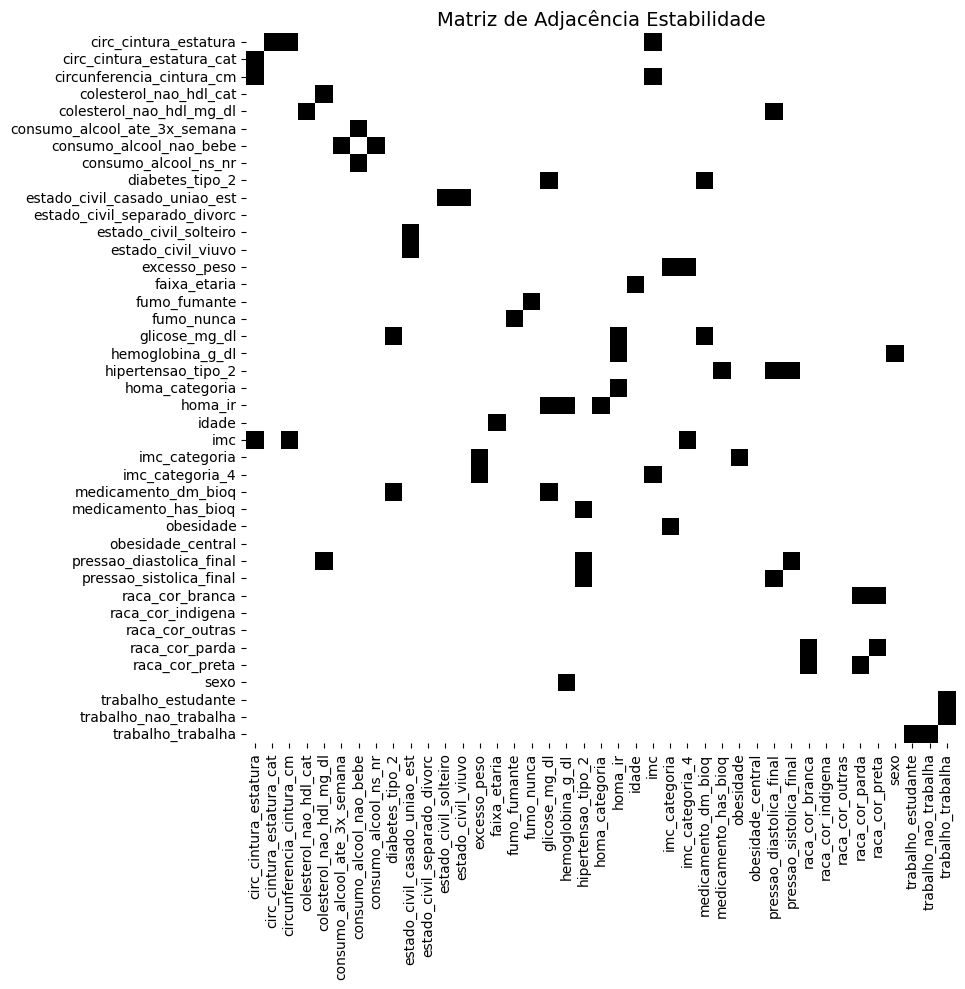

In [13]:
# 1. Cria uma tela maior para legibilidade
plt.figure(figsize=(12, 10))

# 2. Define uma paleta customizada: 0 = Branco, 1 = Preto
# O Seaborn interpola entre essas cores, então o resultado será binário
paleta_custom = mcolors.LinearSegmentedColormap.from_list("", ["white", "black"])

# 3. Gera o heatmap com as configurações corretas
sns.heatmap(
    adj_matrix,
    annot=False,          # Mantém os números visíveis
    cmap=paleta_custom,  # Aplica a paleta personalizada
    cbar=False,          # Remove a barra lateral de cores
    square=True,         # Força células quadradas
    fmt='g',             # Formata números como inteiros simples
    annot_kws={"size": 8} # Ajusta o tamanho da fonte das anotações se necessário
)

# 4. Adiciona o título e formatação final
plt.title("Matriz de Adjacência Estabilidade", fontsize=14)
plt.tight_layout() # Ajusta automaticamente para não cortar os nomes das variáveis
plt.savefig('Teste.jpg')
plt.show()

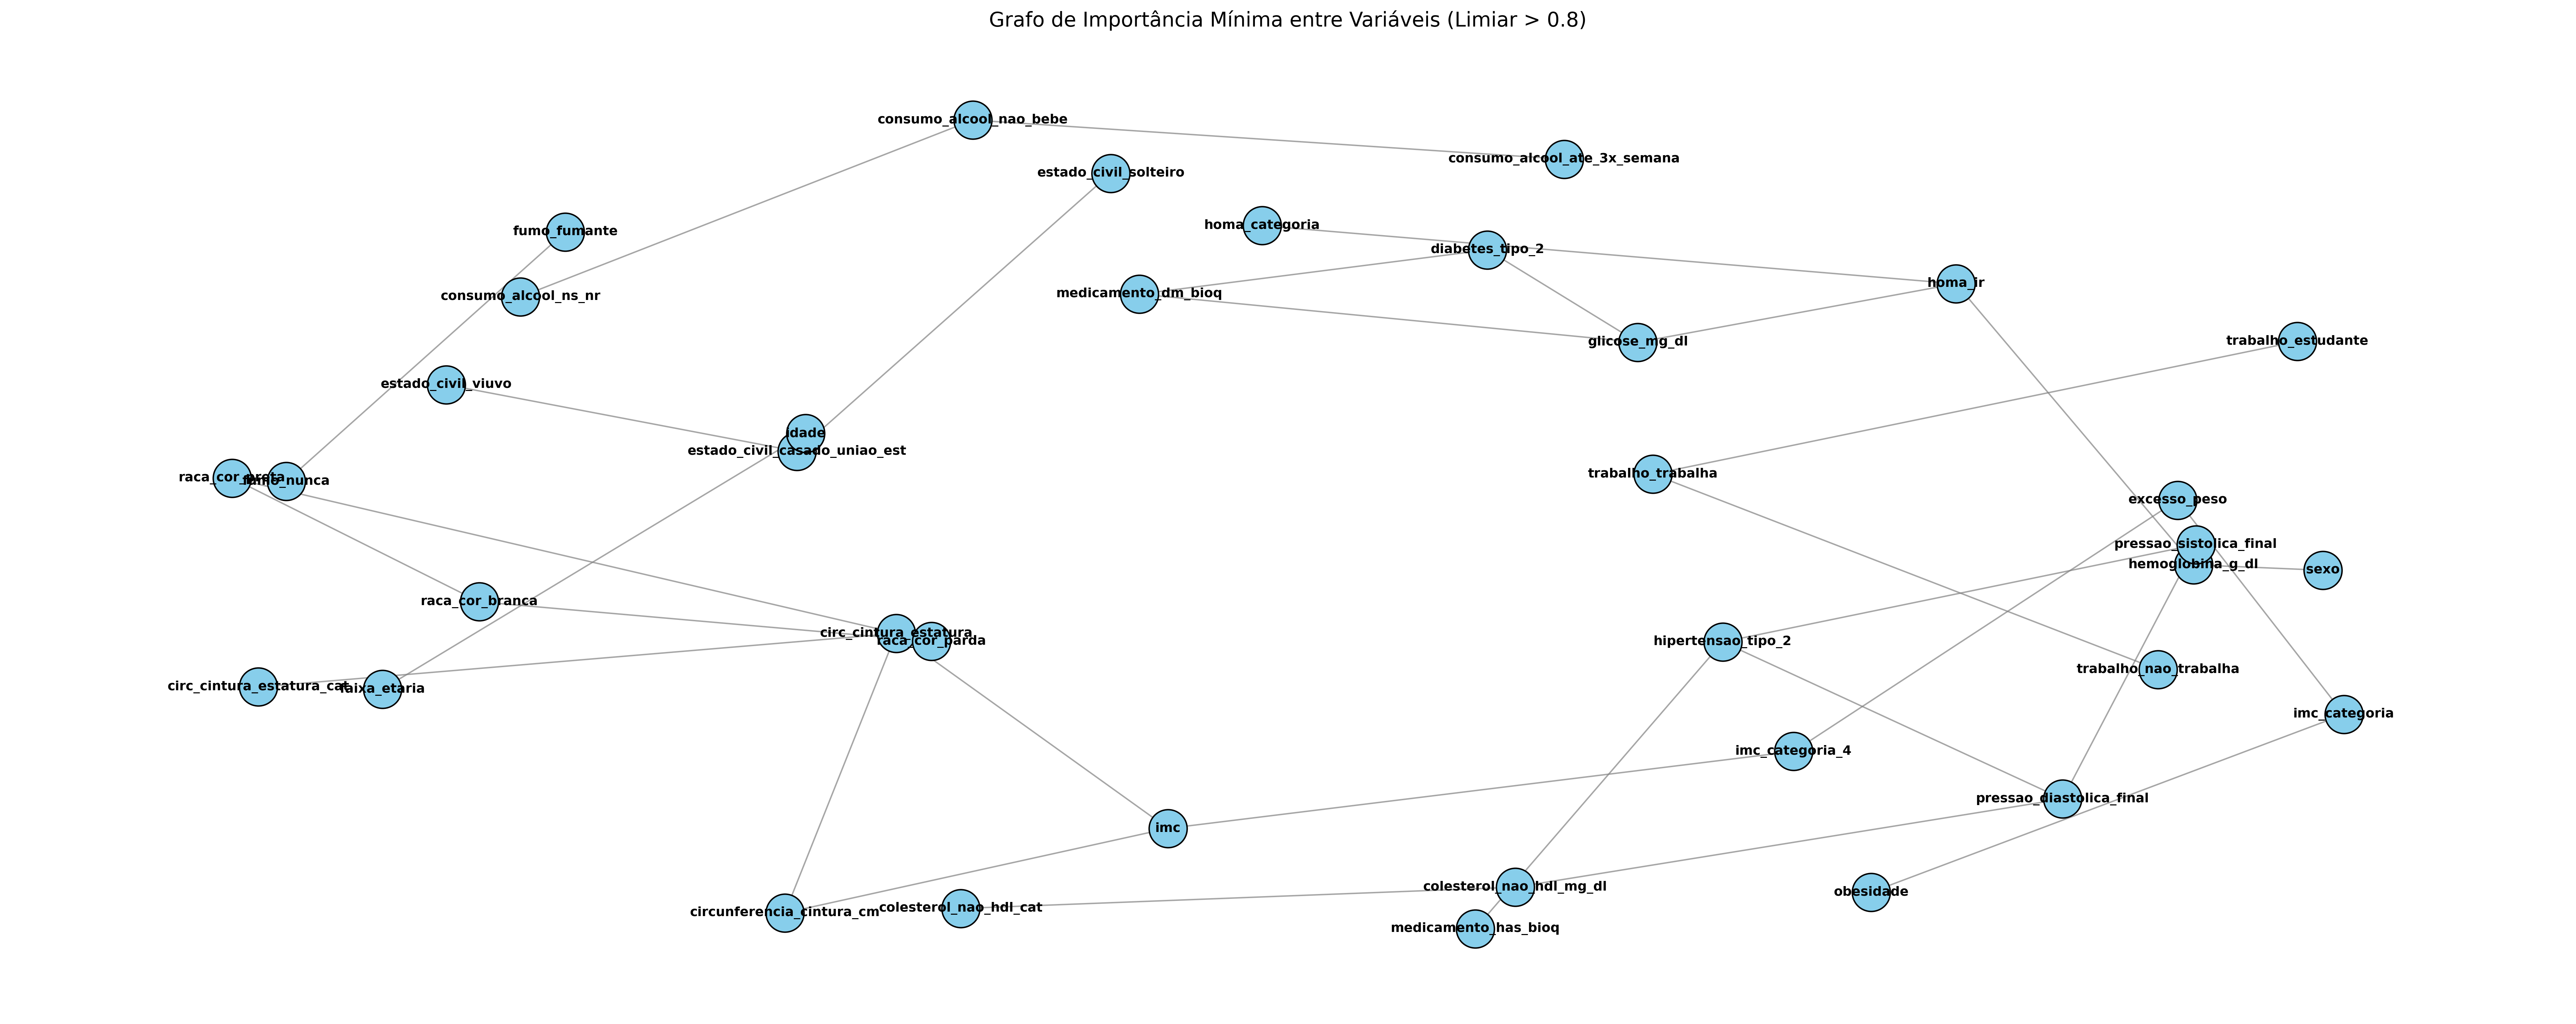

In [14]:
Grafo = nx.from_pandas_adjacency(adj_matrix, create_using=nx.Graph)

arestas_para_remover = [
    (u, v)
    for u, v, d in Grafo.edges(data=True)
    if d["weight"] < 1
]
Grafo.remove_edges_from(arestas_para_remover)

Grafo.remove_nodes_from(list(nx.isolates(Grafo)))

# --- ESTILIZAÇÃO DO GRAFO ---
plt.figure(figsize=(25, 10), dpi=300)

pos = nx.spring_layout(Grafo, weight='weight', iterations=50, k = 5/np.sqrt(len(Grafo)), seed=1)

pesos = np.array([d["weight"] for u, v, d in Grafo.edges(data=True)])

nx.draw_networkx_nodes(
    Grafo, pos, node_size=700, node_color="skyblue", edgecolors="black"
)

if len(pesos) > 0:
    espessura = pesos/pesos.max()
else: 
    espessura = 5
nx.draw_networkx_edges(
    Grafo, pos, width=espessura, edge_color="gray", alpha=0.7, arrows=False
)


# Desenha os Nomes das Variáveis
nx.draw_networkx_labels(Grafo, pos, font_size=9, font_weight="bold")

plt.title(
    f"Grafo de Importância Mínima entre Variáveis (Limiar > {q})",
    fontsize=14,
)
plt.axis("off")
plt.tight_layout()
# plt.savefig('grafo2.png')
plt.show()

In [15]:
matriz_final.to_csv('Matriz_fenotipo.csv')

# Centralidade

In [29]:
grau = nx.degree_centrality(Grafo)
intermediacao = nx.betweenness_centrality(Grafo)
proximidade = nx.closeness_centrality(Grafo)
autovetor = nx.eigenvector_centrality(Grafo, max_iter= 1000, tol=1e-05)

In [20]:
grau

[('circ_cintura_estatura', 0.08333333333333333),
 ('circ_cintura_estatura_cat', 0.027777777777777776),
 ('circunferencia_cintura_cm', 0.05555555555555555),
 ('colesterol_nao_hdl_cat', 0.027777777777777776),
 ('colesterol_nao_hdl_mg_dl', 0.05555555555555555),
 ('consumo_alcool_ate_3x_semana', 0.027777777777777776),
 ('consumo_alcool_nao_bebe', 0.05555555555555555),
 ('consumo_alcool_ns_nr', 0.027777777777777776),
 ('diabetes_tipo_2', 0.05555555555555555),
 ('estado_civil_casado_uniao_est', 0.05555555555555555),
 ('estado_civil_solteiro', 0.027777777777777776),
 ('estado_civil_viuvo', 0.027777777777777776),
 ('excesso_peso', 0.05555555555555555),
 ('faixa_etaria', 0.027777777777777776),
 ('fumo_fumante', 0.027777777777777776),
 ('fumo_nunca', 0.027777777777777776),
 ('glicose_mg_dl', 0.08333333333333333),
 ('hemoglobina_g_dl', 0.05555555555555555),
 ('hipertensao_tipo_2', 0.08333333333333333),
 ('homa_categoria', 0.027777777777777776),
 ('homa_ir', 0.08333333333333333),
 ('idade', 0.0277

In [25]:
intermediacao

{'circ_cintura_estatura': 0.009523809523809525,
 'circ_cintura_estatura_cat': 0.0,
 'circunferencia_cintura_cm': 0.0,
 'colesterol_nao_hdl_cat': 0.0,
 'colesterol_nao_hdl_mg_dl': 0.006349206349206349,
 'consumo_alcool_ate_3x_semana': 0.0,
 'consumo_alcool_nao_bebe': 0.0015873015873015873,
 'consumo_alcool_ns_nr': 0.0,
 'diabetes_tipo_2': 0.0,
 'estado_civil_casado_uniao_est': 0.0015873015873015873,
 'estado_civil_solteiro': 0.0,
 'estado_civil_viuvo': 0.0,
 'excesso_peso': 0.015873015873015872,
 'faixa_etaria': 0.0,
 'fumo_fumante': 0.0,
 'fumo_nunca': 0.0,
 'glicose_mg_dl': 0.012698412698412698,
 'hemoglobina_g_dl': 0.007936507936507936,
 'hipertensao_tipo_2': 0.006349206349206349,
 'homa_categoria': 0.0,
 'homa_ir': 0.01746031746031746,
 'idade': 0.0,
 'imc': 0.01904761904761905,
 'imc_categoria': 0.009523809523809525,
 'imc_categoria_4': 0.01904761904761905,
 'medicamento_dm_bioq': 0.0,
 'medicamento_has_bioq': 0.0,
 'obesidade': 0.0,
 'pressao_diastolica_final': 0.00952380952380952

In [26]:
proximidade

{'circ_cintura_estatura': 0.08006535947712418,
 'circ_cintura_estatura_cat': 0.05917874396135266,
 'circunferencia_cintura_cm': 0.07561728395061729,
 'colesterol_nao_hdl_cat': 0.05341880341880342,
 'colesterol_nao_hdl_mg_dl': 0.0771604938271605,
 'consumo_alcool_ate_3x_semana': 0.037037037037037035,
 'consumo_alcool_nao_bebe': 0.05555555555555555,
 'consumo_alcool_ns_nr': 0.037037037037037035,
 'diabetes_tipo_2': 0.07142857142857142,
 'estado_civil_casado_uniao_est': 0.05555555555555555,
 'estado_civil_solteiro': 0.037037037037037035,
 'estado_civil_viuvo': 0.037037037037037035,
 'excesso_peso': 0.08506944444444445,
 'faixa_etaria': 0.027777777777777776,
 'fumo_fumante': 0.027777777777777776,
 'fumo_nunca': 0.027777777777777776,
 'glicose_mg_dl': 0.09999999999999999,
 'hemoglobina_g_dl': 0.08333333333333333,
 'hipertensao_tipo_2': 0.08680555555555555,
 'homa_categoria': 0.07142857142857142,
 'homa_ir': 0.1111111111111111,
 'idade': 0.027777777777777776,
 'imc': 0.09722222222222222,
 'i

In [30]:
autovetor

{'circ_cintura_estatura': 0.5330259638593207,
 'circ_cintura_estatura_cat': 0.22725280376794452,
 'circunferencia_cintura_cm': 0.46509846276447114,
 'colesterol_nao_hdl_cat': 0.005871547422541535,
 'colesterol_nao_hdl_mg_dl': 0.013705369114675951,
 'consumo_alcool_ate_3x_semana': 7.493383807898161e-127,
 'consumo_alcool_nao_bebe': 1.0597245009196527e-126,
 'consumo_alcool_ns_nr': 7.493383807898161e-127,
 'diabetes_tipo_2': 1.0446339900036109e-06,
 'estado_civil_casado_uniao_est': 1.0597245009196527e-126,
 'estado_civil_solteiro': 7.493383807898161e-127,
 'estado_civil_viuvo': 7.493383807898161e-127,
 'excesso_peso': 0.17011844992394579,
 'faixa_etaria': 2.722830112703548e-199,
 'fumo_fumante': 2.722830112703548e-199,
 'fumo_nunca': 2.722830112703548e-199,
 'glicose_mg_dl': 1.354899416531651e-06,
 'hemoglobina_g_dl': 5.494815679770073e-07,
 'hipertensao_tipo_2': 0.025253866301845604,
 'homa_categoria': 4.4533910776599104e-07,
 'homa_ir': 1.0229478233973687e-06,
 'idade': 2.7228301127035